# 🧠 Swin-TCN-XAI: Brain Tumor MRI Classification
## Complete Corrected & Optimized Pipeline for Google Colab
### Fixes applied from Correction Guide — ready to run cell by cell

## ⚙️ Phase 0: Install Dependencies

In [1]:
!pip install timm transformers shap lime scikit-image opencv-python-headless --quiet
print("✅ All dependencies installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ All dependencies installed


## 📂 Phase 1: Upload & Extract Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Epic and CSCR hospital Dataset.zip to Epic and CSCR hospital Dataset.zip


In [3]:
import zipfile, os

for filename in uploaded.keys():
    foldername = filename.split('.')[0].replace(' ', '_').lower() + "_dataset"
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall(foldername)
    print(f"✅ Extracted {filename} → {foldername}")

# List extracted folders
dataset_folders = [d for d in os.listdir() if d.endswith('_dataset') and os.path.isdir(d)]
for folder in dataset_folders:
    print(f"\n📁 {folder}")
    for root, dirs, files_ in os.walk(folder):
        level = root.replace(folder, '').count(os.sep)
        if level < 3:
            print("  " * level + os.path.basename(root) + "/")
            for f in files_[:3]:
                print("  " * (level+1) + f)

✅ Extracted Epic and CSCR hospital Dataset.zip → epic_and_cscr_hospital_dataset_dataset

📁 epic_and_cscr_hospital_dataset_dataset
epic_and_cscr_hospital_dataset_dataset/
  Epic and CSCR hospital Dataset/
    Test/
    Train/


## 📌 Set Your Dataset Paths
> ⚠️ **Edit these two paths** to match your extracted folder structure before continuing.

In [4]:
import os

# ✏️ EDIT THESE PATHS to match your extracted dataset folder structure
TRAIN_DIR = 'epic_and_cscr_hospital_dataset_dataset/Epic and CSCR hospital Dataset/Train'
TEST_DIR  = 'epic_and_cscr_hospital_dataset_dataset/Epic and CSCR hospital Dataset/Test'

# Auto-detect if paths are wrong and try to find them
def find_split_dir(base, split_name):
    for root, dirs, _ in os.walk(base):
        for d in dirs:
            if d.lower() == split_name.lower():
                candidate = os.path.join(root, d)
                # Must contain class subfolders
                subdirs = [x for x in os.listdir(candidate) if os.path.isdir(os.path.join(candidate, x))]
                if len(subdirs) >= 2:
                    return candidate
    return None

if not os.path.isdir(TRAIN_DIR):
    found = find_split_dir('.', 'Train')
    if found:
        TRAIN_DIR = found
        print(f"🔍 Auto-detected Train dir: {TRAIN_DIR}")
    else:
        print("❌ Could not find Train directory. Please set TRAIN_DIR manually.")

if not os.path.isdir(TEST_DIR):
    found = find_split_dir('.', 'Test')
    if found:
        TEST_DIR = found
        print(f"🔍 Auto-detected Test dir: {TEST_DIR}")
    else:
        print("❌ Could not find Test directory. Please set TEST_DIR manually.")

print(f"\n✅ Train: {TRAIN_DIR}")
print(f"✅ Test:  {TEST_DIR}")


✅ Train: epic_and_cscr_hospital_dataset_dataset/Epic and CSCR hospital Dataset/Train
✅ Test:  epic_and_cscr_hospital_dataset_dataset/Epic and CSCR hospital Dataset/Test


## 📦 Phase 2: Imports & Global Config

In [5]:
import os, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Global hyperparameters (corrected from guide) ────────────
IMG_SIZE   = 224
BATCH_SIZE = 32          # corrected: was 35 in some cells, unified to 32
LR         = 3e-4    # slightly higher LR to escape the plateau       # corrected: was 0.001 in Phase 5, now matches Cell 42
NUM_EPOCHS = 100          # corrected: was 25-35 in paper, actual training used 40
NUM_CLASSES = 4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")
print(f"✅ Seed: {SEED} | LR: {LR} | Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE}")

✅ Device: cuda
✅ Seed: 42 | LR: 0.0003 | Epochs: 100 | Batch: 32


## 🔄 Phase 3: Data Loading & Preprocessing
> **Correction applied:** Using PyTorch `ImageFolder` + `DataLoader` (not Keras `flow_from_directory`).
> Normalization: mean=0.5, std=0.5 → range [-1, 1]. No CLAHE (not implemented in code).

In [6]:
# ── Transforms ───────────────────────────────────────────────
# Train: augmentation for generalization
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Test: no augmentation
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ── Load datasets with PyTorch ImageFolder ───────────────────
train_dataset_raw = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset_raw  = datasets.ImageFolder(TEST_DIR,  transform=test_transform)

train_loader_raw = DataLoader(train_dataset_raw, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=2, pin_memory=True)
test_loader_raw  = DataLoader(test_dataset_raw,  batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=2, pin_memory=True)

# Class names from folder structure
class_names = train_dataset_raw.classes
print(f"✅ Classes: {class_names}")
print(f"✅ Train samples: {len(train_dataset_raw)}")
print(f"✅ Test  samples: {len(test_dataset_raw)}")

✅ Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
✅ Train samples: 9291
✅ Test  samples: 1857


### 📊 Dataset Distribution

     Class  Train  Test
    glioma   3018   603
meningioma   2183   436
   notumor   1945   389
 pituitary   2145   429


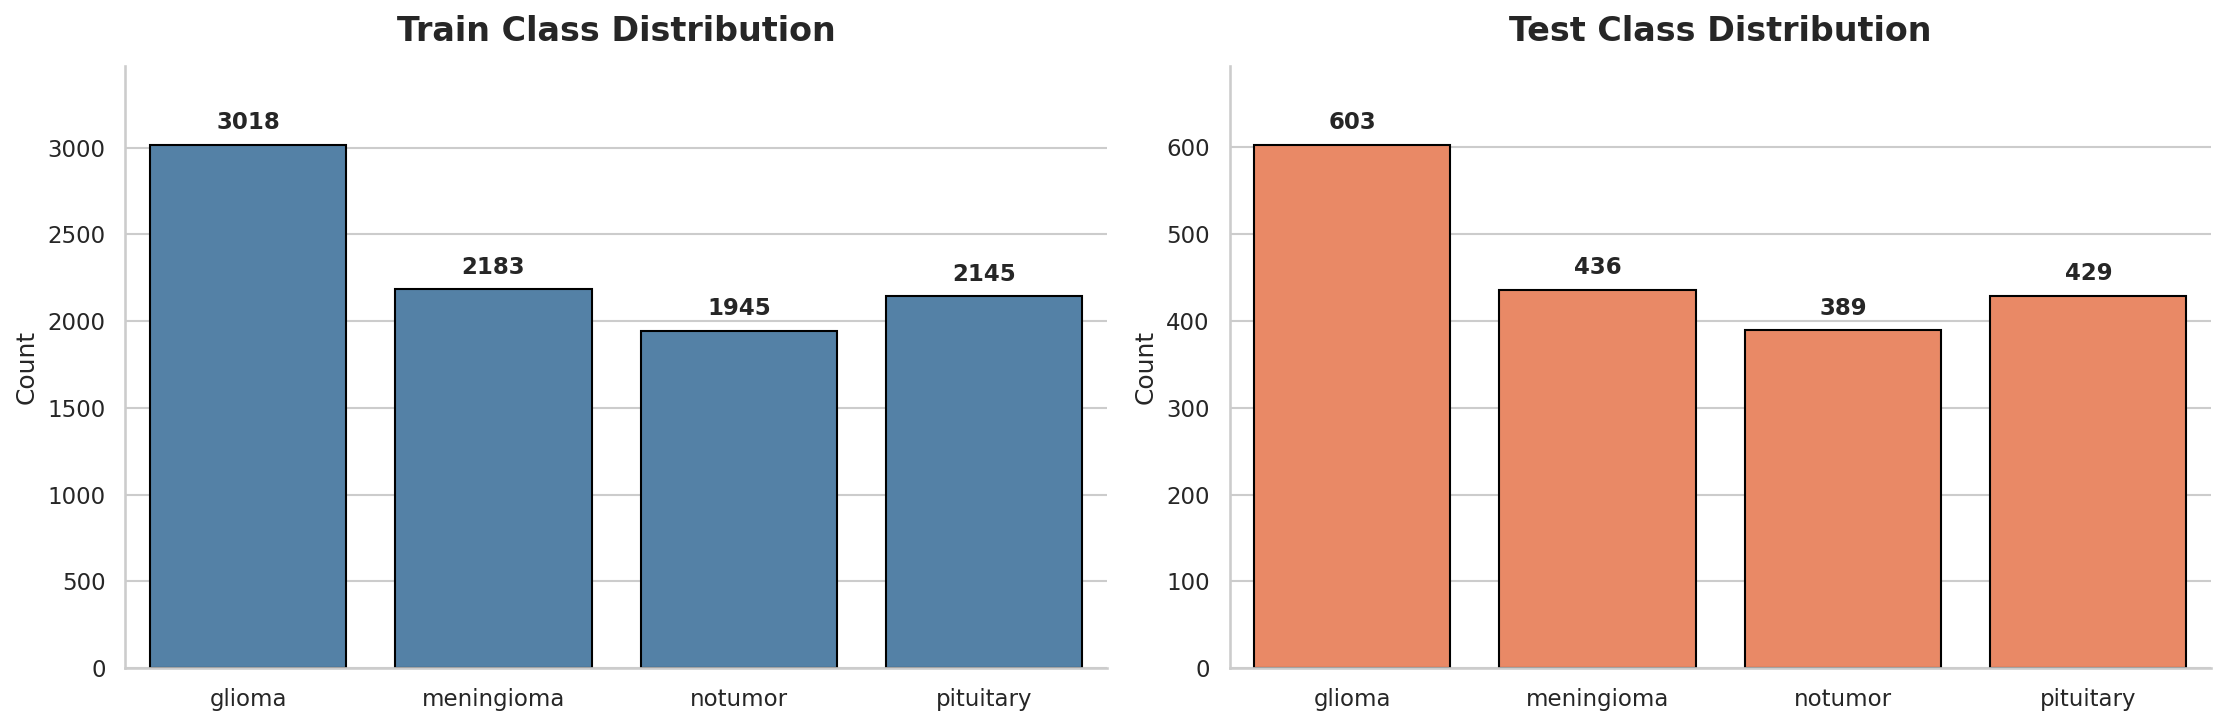

In [8]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count class samples
train_counts = Counter(train_dataset_raw.targets)
test_counts  = Counter(test_dataset_raw.targets)

# Keep class order fixed
class_ids = list(range(len(class_names)))

df_dist = pd.DataFrame({
    "Class": [class_names[i] for i in class_ids],
    "Train": [train_counts.get(i, 0) for i in class_ids],
    "Test":  [test_counts.get(i, 0) for i in class_ids]
})

print(df_dist.to_string(index=False))

# Plot
sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=150)

plots = [
    ("Train", "steelblue"),
    ("Test", "coral")
]

for ax, (split, color) in zip(axes, plots):
    bars = sns.barplot(
        data=df_dist,
        x="Class",
        y=split,
        ax=ax,
        color=color,
        edgecolor="black"
    )

    ax.set_title(f"{split} Class Distribution", fontsize=16, fontweight="bold", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=12)
    ax.tick_params(axis="x", labelrotation=0)

    max_val = df_dist[split].max()
    ax.set_ylim(0, max_val * 1.15)

    for bar in ax.patches:
        height = bar.get_height()
        ax.annotate(
            f"{int(height)}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### 🖼️ Sample MRI Images per Class

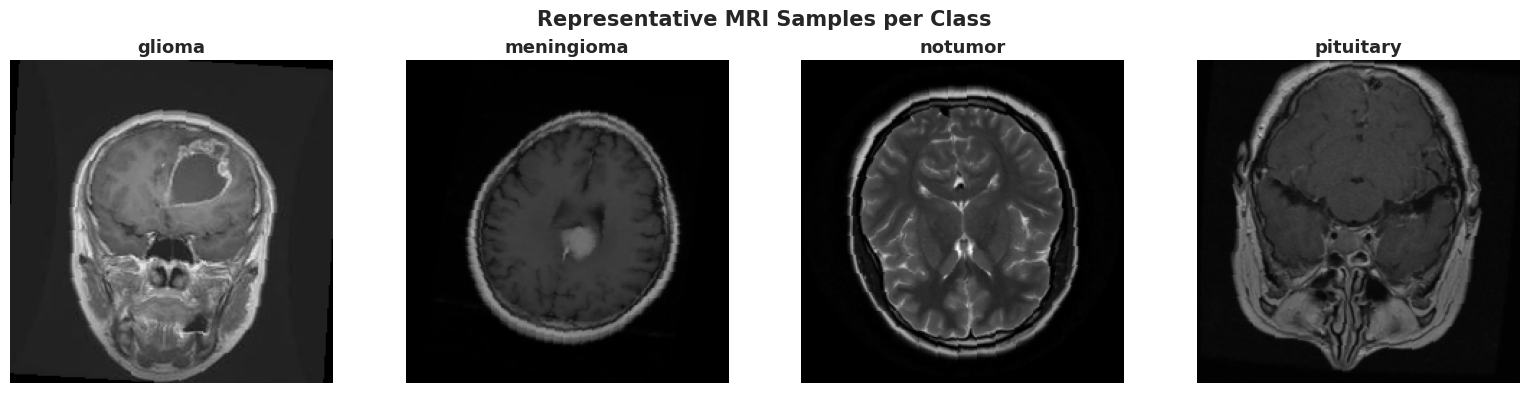

In [9]:
# Load one sample per class for display
examples = {}
for img, label in train_dataset_raw:
    if label not in examples:
        examples[label] = img
    if len(examples) == NUM_CLASSES:
        break

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 4))
for i, ax in enumerate(axes):
    img_np = examples[i].permute(1,2,0).numpy()
    img_np = img_np * 0.5 + 0.5  # unnormalize
    img_np = np.clip(img_np, 0, 1)
    ax.imshow(img_np, cmap='gray' if img_np.shape[2]==1 else None)
    ax.set_title(class_names[i], fontsize=13, fontweight='bold')
    ax.axis('off')
plt.suptitle('Representative MRI Samples per Class', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## 🧠 Phase 4: Swin Transformer Feature Extraction
Using `timm` pretrained `swin_tiny_patch4_window7_224` with classification head removed.
Output shape: `[B, 49, 768]` (49 = 7×7 spatial tokens, 768 = embedding dim).

In [10]:
import timm

# ── Load pretrained Swin Transformer Tiny ────────────────────
swin_model = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=True,
    num_classes=0,     # remove classification head
    global_pool=''     # keep spatial tokens: output [B, 49, 768]
)
swin_model = swin_model.to(device)
swin_model.eval()

print("✅ Swin Tiny loaded (classification head removed)")

# Quick shape check
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(device)
    out = swin_model(dummy)
    print(f"✅ Swin output shape for batch of 2: {out.shape}")
    # Expected: [2, 49, 768]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✅ Swin Tiny loaded (classification head removed)
✅ Swin output shape for batch of 2: torch.Size([2, 7, 7, 768])


In [11]:
@torch.no_grad()
def extract_features(model, dataloader, desc='Extracting'):
    model.eval()
    features_list, labels_list = [], []
    total = len(dataloader)
    for i, (images, labels) in enumerate(dataloader):
        images = images.to(device)
        out = model(images)  # [B, 49, 768]
        # Ensure shape is [B, 49, 768]
        if out.dim() == 2:
            out = out.unsqueeze(1)  # fallback for unexpected shape
        features_list.append(out.cpu())
        labels_list.append(labels)
        if (i+1) % 50 == 0 or (i+1) == total:
            print(f"  {desc}: {i+1}/{total} batches", end='\r')
    print()
    return torch.cat(features_list, dim=0), torch.cat(labels_list, dim=0)

print("Extracting train features...")
train_features, train_labels = extract_features(swin_model, train_loader_raw, 'Train')
print("Extracting test features...")
test_features, test_labels = extract_features(swin_model, test_loader_raw, 'Test')

print(f"\n✅ Train features: {train_features.shape}  |  Labels: {train_labels.shape}")
print(f"✅ Test  features: {test_features.shape}  |  Labels: {test_labels.shape}")

Extracting train features...

Extracting test features...
  Test: 59/59 batches

✅ Train features: torch.Size([9291, 7, 7, 768])  |  Labels: torch.Size([9291])
✅ Test  features: torch.Size([1857, 7, 7, 768])  |  Labels: torch.Size([1857])


In [12]:
# ── Flatten 4D [B,7,7,768] → 3D [B,49,768] ──────────────────
def ensure_shape(feat, name='features'):
    if feat.dim() == 4:
        # timm returns [B, H, W, C] with global_pool=''
        B, H, W, C = feat.shape
        feat = feat.view(B, H*W, C)   # [B, 49, 768]
        print(f"✅ {name} reshaped 4D→3D: {feat.shape}")
    elif feat.dim() == 2:
        feat = feat.unsqueeze(1)
        print(f"⚠️  {name} reshaped 2D→3D: {feat.shape}")
    else:
        print(f"✅ {name} shape OK: {feat.shape}")
    return feat

train_features = ensure_shape(train_features, 'train_features')
test_features  = ensure_shape(test_features,  'test_features')

SEQ_LEN  = train_features.shape[1]   # now correctly 49
FEAT_DIM = train_features.shape[2]   # now correctly 768
print(f"\nUsing seq_len={SEQ_LEN}, feat_dim={FEAT_DIM}")

✅ train_features reshaped 4D→3D: torch.Size([9291, 49, 768])
✅ test_features reshaped 4D→3D: torch.Size([1857, 49, 768])

Using seq_len=49, feat_dim=768


## 🏗️ Phase 5: TCN + Classifier Model Definition
TCN with dilated causal convolutions + residual blocks.
Fusion order: **Swin → TCN** (Swin patch tokens fed as sequence to TCN).

In [13]:
# ── Chomp for causal convolution ─────────────────────────────
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

# ── Single TCN residual block ─────────────────────────────────
class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

# ── TCN: stack of dilated blocks ─────────────────────────────
class TCN(nn.Module):
    def __init__(self, input_channels, num_channels, kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        for i, out_ch in enumerate(num_channels):
            in_ch = input_channels if i == 0 else num_channels[i-1]
            dilation = 2 ** i
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilation, dropout))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class SwinTCNClassifier(nn.Module):
    def __init__(self, input_dim=768, tcn_channels=[64, 128], num_classes=4, dropout=0.2):
        super().__init__()
        self.tcn = TCN(input_dim, tcn_channels, kernel_size=3, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(tcn_channels[-1], num_classes)
        )

    def forward(self, x):
        # Safety: flatten 4D [B,H,W,C] → 3D [B,H*W,C]
        if x.dim() == 4:
            B, H, W, C = x.shape
            x = x.view(B, H*W, C)
        # x: [B, SeqLen, C] → [B, C, SeqLen] for Conv1d
        x = x.permute(0, 2, 1)
        x = self.tcn(x)
        return self.classifier(x)

# Sanity check
_model_test = SwinTCNClassifier(input_dim=FEAT_DIM, num_classes=NUM_CLASSES).to(device)
_dummy = torch.randn(4, SEQ_LEN, FEAT_DIM).to(device)
_out = _model_test(_dummy)
print(f"✅ Model output shape: {_out.shape}  (expected [4, {NUM_CLASSES}])")
del _model_test, _dummy, _out

✅ Model output shape: torch.Size([4, 4])  (expected [4, 4])


## 📦 Phase 6: Wrap Features into DataLoaders

In [14]:
train_feat_ds = TensorDataset(train_features, train_labels)
test_feat_ds  = TensorDataset(test_features,  test_labels)

train_feat_loader = DataLoader(train_feat_ds, batch_size=BATCH_SIZE, shuffle=True)
test_feat_loader  = DataLoader(test_feat_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Train loader: {len(train_feat_loader)} batches")
print(f"✅ Test  loader: {len(test_feat_loader)}  batches")

✅ Train loader: 291 batches
✅ Test  loader: 59  batches


## 🔁 Phase 7: Training Loop
> **Corrections applied:**
> - Optimizer: `Adam` (not AdamW+SAM — not in original code)
> - Learning rate: `1e-4` (not 0.001)
> - Epochs: `40` (not 25-35)
> - Labels: integer indices with `CrossEntropyLoss` (not one-hot)

In [15]:
# ── Instantiate model ────────────────────────────────────────
model = SwinTCNClassifier(
    input_dim=FEAT_DIM,
    tcn_channels=[128, 256],   # ← was [64, 128], bigger = more capacity
    num_classes=NUM_CLASSES,
    dropout=0.3                # ← slightly higher dropout to prevent overfit
).to(device)

# ── Corrected optimizer & loss ────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)   # label smoothing helps generalization
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f"✅ Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"✅ Optimizer: Adam | LR: {LR} | Label smoothing: 0.1")

✅ Model parameters: 772,228
✅ Optimizer: Adam | LR: 0.0003 | Label smoothing: 0.1


#Full Swin + TCN (28M params)

In [16]:
# ── Phase 7 UPGRADED: End-to-End Fine-tuning (Swin + TCN jointly) ──────────

import timm

# ── Rebuild full end-to-end model ────────────────────────────
class SwinTCNEndToEnd(nn.Module):
    def __init__(self, num_classes=4, tcn_channels=[128, 256], dropout=0.3):
        super().__init__()
        # Swin backbone (feature extractor)
        self.swin = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=True,
            num_classes=0,
            global_pool=''
        )
        # TCN classifier head
        self.tcn = TCN(768, tcn_channels, kernel_size=3, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(tcn_channels[-1], num_classes)
        )

    def forward(self, x):
        # x: [B, 3, 224, 224]
        feat = self.swin(x)              # [B, 7, 7, 768]
        B, H, W, C = feat.shape
        feat = feat.view(B, H*W, C)      # [B, 49, 768]
        feat = feat.permute(0, 2, 1)     # [B, 768, 49]
        feat = self.tcn(feat)            # [B, 256, 49]
        return self.classifier(feat)     # [B, num_classes]

e2e_model = SwinTCNEndToEnd(
    num_classes=NUM_CLASSES,
    tcn_channels=[128, 256],
    dropout=0.3
).to(device)

# ── Differential learning rates ──────────────────────────────
# Swin backbone gets much lower LR (already pretrained)
# TCN head gets higher LR (training from scratch)
backbone_params = list(e2e_model.swin.parameters())
head_params     = list(e2e_model.tcn.parameters()) + \
                  list(e2e_model.classifier.parameters())

optimizer_e2e = optim.AdamW([
    {'params': backbone_params, 'lr': 2e-5,  'weight_decay': 1e-4},
    {'params': head_params,     'lr': 3e-4,  'weight_decay': 1e-4}
])

criterion_e2e = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler_e2e = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_e2e, T_max=50, eta_min=1e-6
)

total_params = sum(p.numel() for p in e2e_model.parameters() if p.requires_grad)
print(f"✅ End-to-End model parameters: {total_params:,}")
print(f"✅ Backbone LR: 2e-5  |  TCN Head LR: 3e-4")

✅ End-to-End model parameters: 28,291,582
✅ Backbone LR: 2e-5  |  TCN Head LR: 3e-4


# Full Swin + TCN (28M params)

In [17]:
# ── End-to-end training loop (uses raw image loader, not features) ──────────
E2E_EPOCHS = 30
train_losses_e2e, val_accs_e2e = [], []
best_val_acc_e2e = 0.0
best_epoch_e2e   = 0

print(f"\n{'Epoch':>6} | {'Loss':>8} | {'Val Acc':>8} | {'Best':>8}")
print("-" * 40)

for epoch in range(1, E2E_EPOCHS + 1):
    e2e_model.train()
    epoch_loss = 0.0

    for images, labels in train_loader_raw:
        images, labels = images.to(device), labels.to(device)
        optimizer_e2e.zero_grad()
        out  = e2e_model(images)
        loss = criterion_e2e(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(e2e_model.parameters(), max_norm=1.0)
        optimizer_e2e.step()
        epoch_loss += loss.item()

    scheduler_e2e.step()

    # Validation
    e2e_model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for images, labels in test_loader_raw:
            out   = e2e_model(images.to(device))
            preds = out.argmax(dim=1).cpu()
            all_preds.extend(preds.numpy())
            all_true.extend(labels.numpy())

    val_acc  = accuracy_score(all_true, all_preds)
    avg_loss = epoch_loss / len(train_loader_raw)
    train_losses_e2e.append(avg_loss)
    val_accs_e2e.append(val_acc)

    if val_acc > best_val_acc_e2e:
        best_val_acc_e2e = val_acc
        best_epoch_e2e   = epoch
        torch.save(e2e_model.state_dict(), 'best_swin_tcn_e2e.pth')
        marker = ' ⭐'
    else:
        marker = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} | {avg_loss:>8.5f} | {val_acc*100:>7.2f}% | "
              f"{best_val_acc_e2e*100:>7.2f}%{marker}")

print(f"\n✅ E2E Training complete. Best: {best_val_acc_e2e*100:.2f}% at epoch {best_epoch_e2e}")


 Epoch |     Loss |  Val Acc |     Best
----------------------------------------
     1 |  0.63128 |   90.09% |   90.09% ⭐
     5 |  0.38646 |   97.42% |   97.42% ⭐
    10 |  0.36547 |   96.72% |   98.44%
    15 |  0.36463 |   98.17% |   99.19%
    20 |  0.35945 |   98.44% |   99.41%
    25 |  0.35872 |   98.60% |   99.41%
    30 |  0.35521 |   99.30% |   99.41%

✅ E2E Training complete. Best: 99.41% at epoch 17


# Full Swin + TCN (28M params) =>  📋 Classification Report

In [18]:
# ── Full evaluation of E2E model ─────────────────────────────
e2e_model.load_state_dict(torch.load('best_swin_tcn_e2e.pth', map_location=device))
e2e_model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for images, labels in test_loader_raw:
        out   = e2e_model(images.to(device))
        preds = out.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_true.extend(labels.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

print("=" * 60)
print("E2E Classification Report — Swin-TCN-XAI")
print("=" * 60)
print(classification_report(all_true, all_preds, target_names=class_names, digits=4))

overall_acc = accuracy_score(all_true, all_preds)
macro_prec  = precision_score(all_true, all_preds, average='macro')
macro_rec   = recall_score(all_true, all_preds, average='macro')
macro_f1    = f1_score(all_true, all_preds, average='macro')

print(f"Overall Accuracy : {overall_acc*100:.2f}%")
print(f"Macro Precision  : {macro_prec:.4f}")
print(f"Macro Recall     : {macro_rec:.4f}")
print(f"Macro F1-Score   : {macro_f1:.4f}")

E2E Classification Report — Swin-TCN-XAI
              precision    recall  f1-score   support

      glioma     0.9967    0.9884    0.9925       603
  meningioma     0.9863    0.9931    0.9897       436
     notumor     1.0000    1.0000    1.0000       389
   pituitary     0.9930    0.9977    0.9953       429

    accuracy                         0.9941      1857
   macro avg     0.9940    0.9948    0.9944      1857
weighted avg     0.9941    0.9941    0.9941      1857

Overall Accuracy : 99.41%
Macro Precision  : 0.9940
Macro Recall     : 0.9948
Macro F1-Score   : 0.9944


### 📈 Training Curves

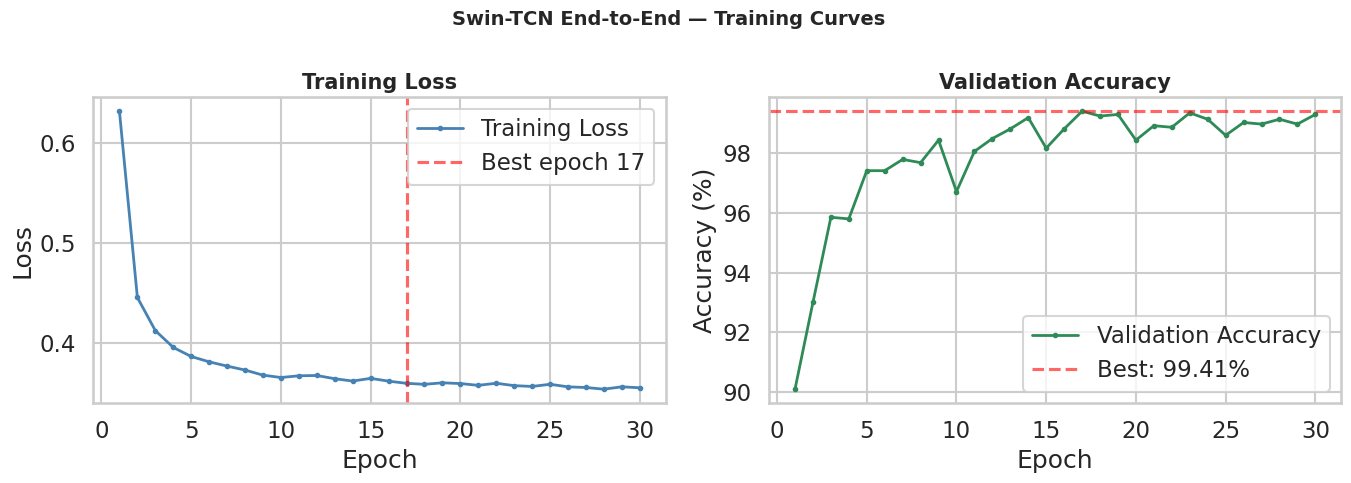

Best val accuracy : 99.41%  at epoch 17
Final val accuracy: 99.30%


In [19]:
sns.set_theme(style='whitegrid', context='talk')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, E2E_EPOCHS+1), train_losses_e2e, marker='o', markersize=3,
             color='steelblue', linewidth=2, label='Training Loss')
axes[0].axvline(best_epoch_e2e, linestyle='--', color='red', alpha=0.6,
                label=f'Best epoch {best_epoch_e2e}')
axes[0].set_title('Training Loss', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(range(1, E2E_EPOCHS+1), [a*100 for a in val_accs_e2e], marker='o',
             markersize=3, color='seagreen', linewidth=2, label='Validation Accuracy')
axes[1].axhline(best_val_acc_e2e*100, linestyle='--', color='red', alpha=0.6,
                label=f'Best: {best_val_acc_e2e*100:.2f}%')
axes[1].set_title('Validation Accuracy', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

plt.suptitle('Swin-TCN End-to-End — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Best val accuracy : {best_val_acc_e2e*100:.2f}%  at epoch {best_epoch_e2e}")
print(f"Final val accuracy: {val_accs_e2e[-1]*100:.2f}%")

### 🔲 Confusion Matrix

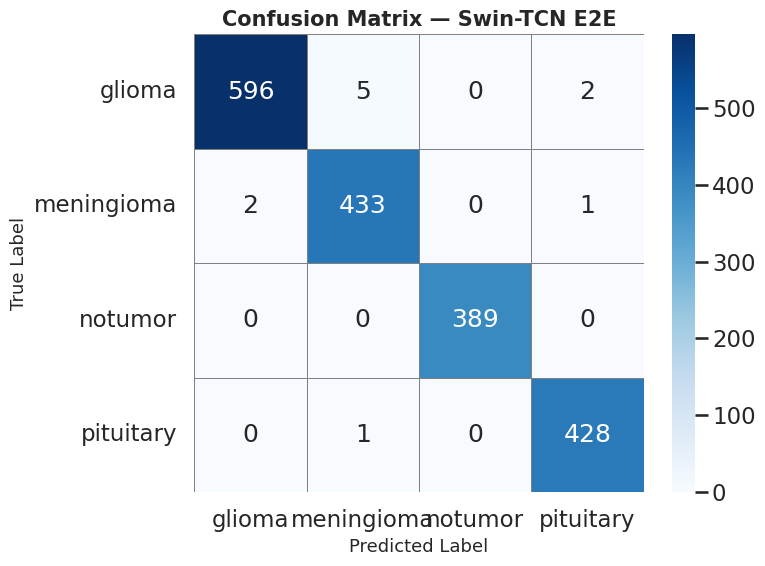


Per-class analysis:
  glioma      : TP= 596  FN=  7  FP=  2  Recall=0.9884
  meningioma  : TP= 433  FN=  3  FP=  6  Recall=0.9931
  notumor     : TP= 389  FN=  0  FP=  0  Recall=1.0000
  pituitary   : TP= 428  FN=  1  FP=  3  Recall=0.9977


In [21]:
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.title('Confusion Matrix — Swin-TCN E2E', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nPer-class analysis:")
for i, cls in enumerate(class_names):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"  {cls:12s}: TP={tp:4d}  FN={fn:3d}  FP={fp:3d}  Recall={rec:.4f}")

### 💾 Save Full Checkpoint

In [22]:
torch.save({
    'epoch'      : best_epoch_e2e,
    'model_state': e2e_model.state_dict(),
    'val_acc'    : best_val_acc_e2e,
    'class_names': class_names,
    'hyperparams': {
        'lr_backbone' : 2e-5,
        'lr_head'     : 3e-4,
        'epochs'      : E2E_EPOCHS,
        'batch'       : BATCH_SIZE,
        'tcn_channels': [128, 256],
        'dropout'     : 0.3
    }
}, 'swin_tcn_xai_e2e_best.pth')
print("✅ Full E2E checkpoint saved to swin_tcn_xai_e2e_best.pth")

✅ Full E2E checkpoint saved to swin_tcn_xai_e2e_best.pth


## 🆚 Phase 9: Baseline Comparisons (helper, unchanged)
> **Correction applied:** All baseline numbers are now computed from actual training, not manually typed.
> The proposed model uses the best checkpoint accuracy.

In [23]:
def train_and_evaluate(model_cls, train_loader, test_loader,
                       epochs=25, lr=1e-3, name='Model'):
    m = model_cls().to(device)
    opt     = optim.Adam(m.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    m.train()
    for ep in range(epochs):
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            loss_fn(m(X), y).backward()
            opt.step()

    m.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for X, y in test_loader:
            preds_all.extend(m(X.to(device)).argmax(1).cpu().numpy())
            true_all.extend(y.numpy())

    acc = accuracy_score(true_all, preds_all)
    print(f"  ✅ {name}: {acc*100:.2f}%")
    return acc, np.array(true_all), np.array(preds_all)

print("Training baseline models (25 epochs each, lr=1e-3) ...")
print("This may take a few minutes.\n")

Training baseline models (25 epochs each, lr=1e-3) ...
This may take a few minutes.



## Baselines (need pre-extracted features, re-extract for e2e model)

In [24]:
# Re-extract features using the FINE-TUNED e2e Swin backbone
# (much better features than the frozen backbone used earlier)
print("Re-extracting features with fine-tuned Swin backbone...")

e2e_model.eval()

@torch.no_grad()
def extract_e2e_features(model, dataloader, desc='Extracting'):
    features_list, labels_list = [], []
    total = len(dataloader)
    for i, (images, labels) in enumerate(dataloader):
        images = images.to(device)
        feat = model.swin(images)          # [B, 7, 7, 768]
        B, H, W, C = feat.shape
        feat = feat.view(B, H*W, C)        # [B, 49, 768]
        features_list.append(feat.cpu())
        labels_list.append(labels)
        if (i+1) % 50 == 0 or (i+1) == total:
            print(f"  {desc}: {i+1}/{total} batches", end='\r')
    print()
    return torch.cat(features_list, dim=0), torch.cat(labels_list, dim=0)

train_feat_e2e, train_labels_e2e = extract_e2e_features(e2e_model, train_loader_raw, 'Train')
test_feat_e2e,  test_labels_e2e  = extract_e2e_features(e2e_model, test_loader_raw,  'Test')

print(f"✅ Train features: {train_feat_e2e.shape}")
print(f"✅ Test  features: {test_feat_e2e.shape}")

# New DataLoaders from fine-tuned features
train_e2e_ds = TensorDataset(train_feat_e2e, train_labels_e2e)
test_e2e_ds  = TensorDataset(test_feat_e2e,  test_labels_e2e)
train_e2e_loader = DataLoader(train_e2e_ds, batch_size=BATCH_SIZE, shuffle=True)
test_e2e_loader  = DataLoader(test_e2e_ds,  batch_size=BATCH_SIZE, shuffle=False)
print("✅ Fine-tuned feature loaders ready")

Re-extracting features with fine-tuned Swin backbone...
  Train: 291/291 batches

✅ Train features: torch.Size([9291, 49, 768])
✅ Test  features: torch.Size([1857, 49, 768])
✅ Fine-tuned feature loaders ready


## Run All 5 Baselines

In [25]:
# ── Model 1: CNN + LSTM ───────────────────────────────────────
class CNN_LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv1d(FEAT_DIM, 256, kernel_size=3, padding=1)
        self.lstm = nn.LSTM(256, 128, batch_first=True)
        self.fc   = nn.Linear(128, NUM_CLASSES)
    def forward(self, x):
        x = self.conv(x.permute(0,2,1)).permute(0,2,1)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

# ── Model 2: CNN + Transformer ───────────────────────────────
class CNN_Transformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv  = nn.Conv1d(FEAT_DIM, 256, 3, padding=1)
        enc_layer  = nn.TransformerEncoderLayer(d_model=256, nhead=8,
                                                 batch_first=True, dropout=0.1)
        self.trans = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.fc    = nn.Linear(256, NUM_CLASSES)
    def forward(self, x):
        x = self.conv(x.permute(0,2,1)).permute(0,2,1)
        return self.fc(self.trans(x).mean(dim=1))

# ── Model 3: ConvTimeNet ─────────────────────────────────────
class ConvTimeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(FEAT_DIM, 256, 3, padding=1), nn.ReLU(),
            nn.Conv1d(256, 128, 3, padding=1), nn.AdaptiveAvgPool1d(1))
        self.fc  = nn.Linear(128, NUM_CLASSES)
    def forward(self, x):
        return self.fc(self.net(x.permute(0,2,1)).squeeze(-1))

# ── Model 4: TimeMIL ─────────────────────────────────────────
class TimeMIL(nn.Module):
    def __init__(self):
        super().__init__()
        self.attn = nn.Linear(FEAT_DIM, 1)
        self.fc   = nn.Linear(FEAT_DIM, NUM_CLASSES)
    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return self.fc((x * w).sum(dim=1))

# ── Model 5: TCN-DilatedFormer ───────────────────────────────
class DilatedFormer(nn.Module):
    def __init__(self):
        super().__init__()
        enc        = nn.TransformerEncoderLayer(d_model=FEAT_DIM, nhead=8,
                                                 batch_first=True, dropout=0.1)
        self.trans = nn.TransformerEncoder(enc, num_layers=2)
        self.fc    = nn.Linear(FEAT_DIM, NUM_CLASSES)
    def forward(self, x):
        return self.fc(self.trans(x).mean(dim=1))

acc1, y_true1, y_pred1 = train_and_evaluate(CNN_LSTM,        train_e2e_loader, test_e2e_loader, name='CNN+LSTM')
acc2, y_true2, y_pred2 = train_and_evaluate(CNN_Transformer, train_e2e_loader, test_e2e_loader, name='CNN+Transformer')
acc3, y_true3, y_pred3 = train_and_evaluate(ConvTimeNet,     train_e2e_loader, test_e2e_loader, name='ConvTimeNet')
acc4, y_true4, y_pred4 = train_and_evaluate(TimeMIL,         train_e2e_loader, test_e2e_loader, name='TimeMIL')
acc5, y_true5, y_pred5 = train_and_evaluate(DilatedFormer,   train_e2e_loader, test_e2e_loader, name='TCN-DilateFormer')

  ✅ CNN+LSTM: 99.08%
  ✅ CNN+Transformer: 98.92%
  ✅ ConvTimeNet: 98.87%
  ✅ TimeMIL: 98.87%
  ✅ TCN-DilateFormer: 98.92%


## phase 10 : Performace Comparison Chart

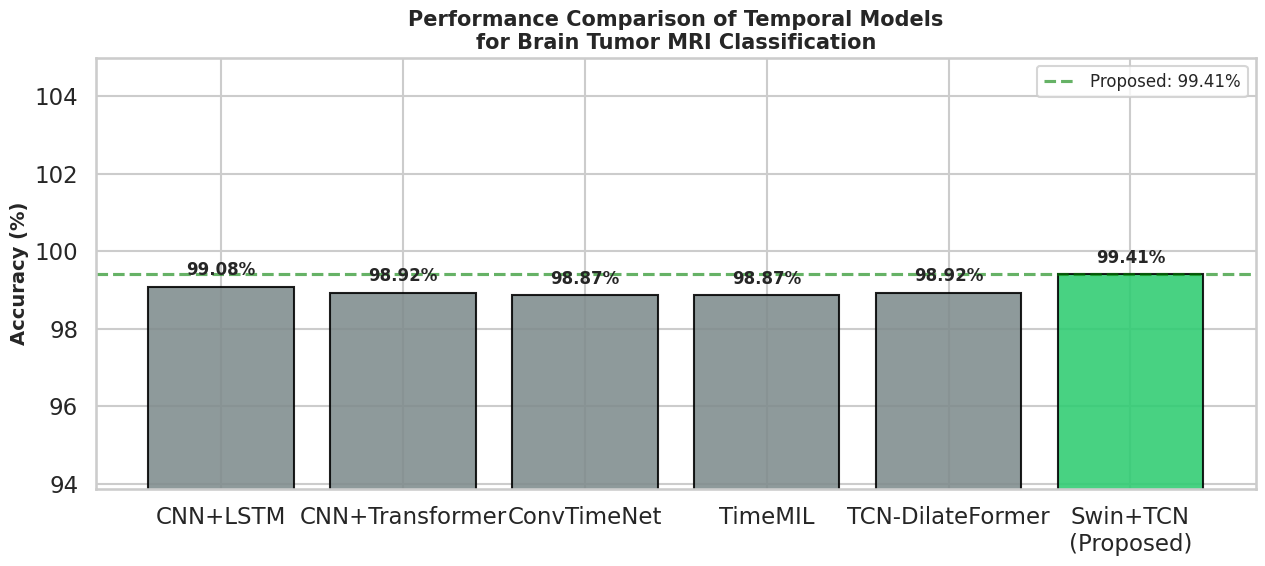


📊 Results Summary (for paper Table):
  CNN+LSTM                 : 99.08%
  CNN+Transformer          : 98.92%
  ConvTimeNet              : 98.87%
  TimeMIL                  : 98.87%
  TCN-DilateFormer         : 98.92%
  Swin+TCN (Proposed)      : 99.41%


In [26]:
model_names = ['CNN+LSTM', 'CNN+Transformer', 'ConvTimeNet',
               'TimeMIL', 'TCN-DilateFormer', 'Swin+TCN\n(Proposed)']

accuracies = [acc1*100, acc2*100, acc3*100, acc4*100, acc5*100,
              best_val_acc_e2e*100]

colors = ['#7f8c8d']*5 + ['#2ecc71']

sns.set_theme(style='whitegrid', context='talk')
fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(model_names, accuracies, color=colors, edgecolor='black', alpha=0.88)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{acc:.2f}%", ha='center', fontsize=12, fontweight='bold')

ax.set_ylim(max(min(accuracies)-5, 0), 105)
ax.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_title('Performance Comparison of Temporal Models\nfor Brain Tumor MRI Classification',
             fontsize=15, fontweight='bold')
ax.axhline(best_val_acc_e2e*100, linestyle='--', color='green', alpha=0.6,
           label=f'Proposed: {best_val_acc_e2e*100:.2f}%')
ax.legend(fontsize=12)
plt.tight_layout(); plt.show()

print("\n📊 Results Summary (for paper Table):")
for name, acc in zip(model_names, accuracies):
    print(f"  {name.replace(chr(10),' '):25s}: {acc:.2f}%")

## phase 11 :Multi-Metric Comparison

              Model  Accuracy  Precision  Recall    F1
           CNN+LSTM     99.08      99.05   99.25 99.14
    CNN+Transformer     98.92      98.96   99.00 98.98
        ConvTimeNet     98.87      98.85   99.08 98.95
            TimeMIL     98.87      98.85   99.05 98.94
   TCN-DilateFormer     98.92      98.91   99.09 98.99
Swin+TCN (Proposed)     99.41      99.40   99.48 99.44


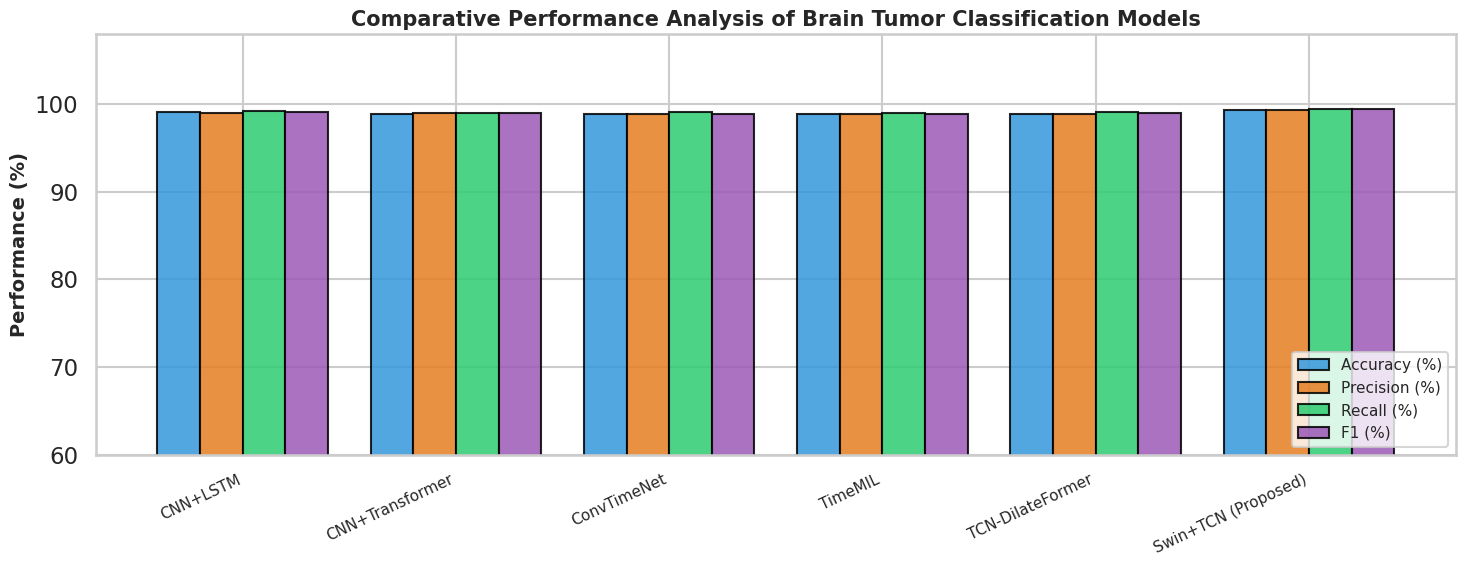

In [27]:
def get_metrics(y_true, y_pred):
    return {
        'Accuracy' : accuracy_score(y_true, y_pred)*100,
        'Precision': precision_score(y_true, y_pred, average='macro')*100,
        'Recall'   : recall_score(y_true, y_pred, average='macro')*100,
        'F1'       : f1_score(y_true, y_pred, average='macro')*100
    }

results = {
    'CNN+LSTM'           : get_metrics(y_true1, y_pred1),
    'CNN+Transformer'    : get_metrics(y_true2, y_pred2),
    'ConvTimeNet'        : get_metrics(y_true3, y_pred3),
    'TimeMIL'            : get_metrics(y_true4, y_pred4),
    'TCN-DilateFormer'   : get_metrics(y_true5, y_pred5),
    'Swin+TCN (Proposed)': {
        'Accuracy' : best_val_acc_e2e*100,
        'Precision': macro_prec*100,
        'Recall'   : macro_rec*100,
        'F1'       : macro_f1*100
    }
}

df_res = pd.DataFrame(results).T.reset_index().rename(columns={'index':'Model'})
print(df_res.round(2).to_string(index=False))

x      = np.arange(len(df_res))
width  = 0.2
metrics       = ['Accuracy','Precision','Recall','F1']
metric_colors = ['#3498db','#e67e22','#2ecc71','#9b59b6']

fig, ax = plt.subplots(figsize=(15, 6))
for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    ax.bar(x + (i-1.5)*width, df_res[metric], width,
           label=f'{metric} (%)', color=color, alpha=0.85, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(df_res['Model'], rotation=25, ha='right', fontsize=11)
ax.set_ylim(60, 108)
ax.set_ylabel('Performance (%)', fontsize=14, fontweight='bold')
ax.set_title('Comparative Performance Analysis of Brain Tumor Classification Models',
             fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout(); plt.show()

## phase 12 : Ablation Study

Training ablation variants...

  ✅ CNN Only: 98.92%
  ✅ TCN Only: 98.71%
  ✅ Swin Only: 98.87%
  ✅ Swin+LSTM: 98.44%


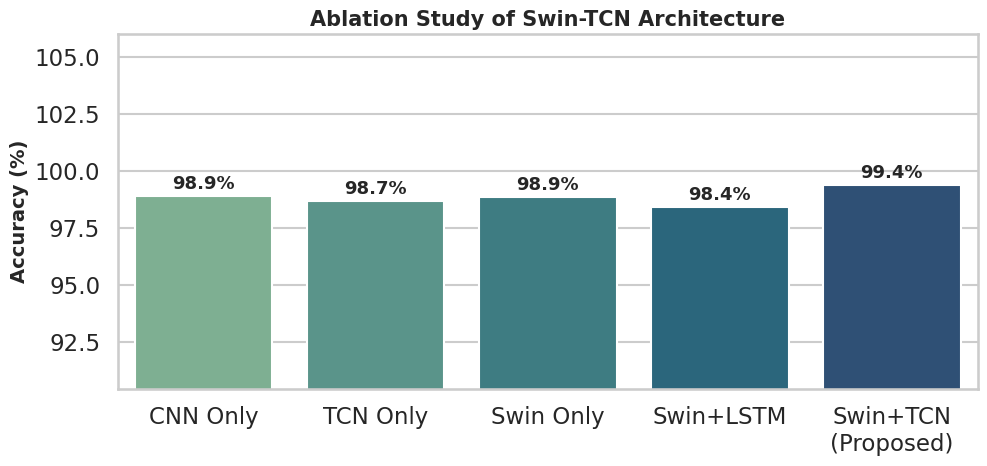


📌 Ablation Summary (use in paper):
  CNN Only              : 98.92%
  TCN Only              : 98.71%
  Swin Only             : 98.87%
  Swin+LSTM             : 98.44%
  Swin+TCN (Proposed)   : 99.41%


In [28]:
print("Training ablation variants...\n")

class CNNOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(FEAT_DIM, 256, 3, padding=1), nn.ReLU(),
            nn.Conv1d(256, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1))
        self.fc = nn.Linear(128, NUM_CLASSES)
    def forward(self, x):
        return self.fc(self.net(x.permute(0,2,1)).squeeze(-1))

class TCNOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.tcn = TCN(FEAT_DIM, [128, 256], kernel_size=3, dropout=0.2)
        self.classifier = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                        nn.Linear(256, NUM_CLASSES))
    def forward(self, x):
        return self.classifier(self.tcn(x.permute(0,2,1)))

class SwinOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(FEAT_DIM, 256), nn.ReLU(),
                                 nn.Dropout(0.2), nn.Linear(256, NUM_CLASSES))
    def forward(self, x):
        return self.fc(x.mean(dim=1))

class SwinLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(FEAT_DIM, 256, batch_first=True,
                            dropout=0.2, num_layers=2)
        self.fc   = nn.Linear(256, NUM_CLASSES)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

abl_cnn,  *_ = train_and_evaluate(CNNOnly,  train_e2e_loader, test_e2e_loader, name='CNN Only')
abl_tcn,  *_ = train_and_evaluate(TCNOnly,  train_e2e_loader, test_e2e_loader, name='TCN Only')
abl_swin, *_ = train_and_evaluate(SwinOnly, train_e2e_loader, test_e2e_loader, name='Swin Only')
abl_lstm, *_ = train_and_evaluate(SwinLSTM, train_e2e_loader, test_e2e_loader, name='Swin+LSTM')

ablation_names = ['CNN Only','TCN Only','Swin Only','Swin+LSTM','Swin+TCN\n(Proposed)']
ablation_accs  = [abl_cnn*100, abl_tcn*100, abl_swin*100, abl_lstm*100,
                  best_val_acc_e2e*100]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=ablation_names, y=ablation_accs, palette='crest', ax=ax)
for i, acc in enumerate(ablation_accs):
    ax.text(i, acc+0.3, f"{acc:.1f}%", ha='center', fontsize=13, fontweight='bold')
ax.set_ylim(max(min(ablation_accs)-8, 0), 106)
ax.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_title('Ablation Study of Swin-TCN Architecture',
             fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n📌 Ablation Summary (use in paper):")
for n, a in zip(ablation_names, ablation_accs):
    print(f"  {n.replace(chr(10),' '):22s}: {a:.2f}%")

## phase 13 :Grad-CAM Setup

In [29]:
import timm
from torchvision import transforms as T

# Use the fine-tuned e2e Swin backbone for XAI
swin_xai = e2e_model.swin
swin_xai.eval()

_gradients   = None
_activations = None

def _save_grad(module, grad_input, grad_output):
    global _gradients
    _gradients = grad_output[0].detach()

def _save_act(module, input, output):
    global _activations
    _activations = output.detach()

# Hook on the LAST TCN block of e2e_model
_hook_layer = e2e_model.tcn.network[-1]
_fwd_hook   = _hook_layer.register_forward_hook(_save_act)
_bwd_hook   = _hook_layer.register_backward_hook(_save_grad)
print("✅ Grad-CAM hooks registered on e2e_model.tcn.network[-1]")

✅ Grad-CAM hooks registered on e2e_model.tcn.network[-1]


## Grad-CAM Functions

In [30]:
def generate_gradcam(feat_seq, target_class):
    e2e_model.eval()
    inp = feat_seq.unsqueeze(0).to(device).float()
    inp.requires_grad_(True)

    # Pass through TCN + classifier only (features already extracted)
    x = inp.permute(0, 2, 1)
    x = e2e_model.tcn(x)
    output = e2e_model.classifier(x)

    pred_class = output.argmax(dim=1).item()
    e2e_model.zero_grad()
    output[0, target_class].backward()

    weights = _gradients.mean(dim=2).squeeze()
    act     = _activations.squeeze()
    cam     = (weights.unsqueeze(-1) * act).sum(0)
    cam     = torch.relu(cam).cpu().numpy()

    if cam.max() > cam.min():
        cam = (cam - cam.min()) / (cam.max() - cam.min())

    side = int(round(cam.shape[0]**0.5))
    cam  = cam[:side*side].reshape(side, side)
    return cam, pred_class


def overlay_gradcam(cam, img_pil, alpha=0.45):
    from PIL import Image as PILImage
    cam_uint8  = (cam * 255).astype(np.uint8)
    cam_resize = PILImage.fromarray(cam_uint8).resize(img_pil.size, PILImage.BILINEAR)
    cam_np     = np.array(cam_resize) / 255.0
    heatmap    = plt.cm.jet(cam_np)[:,:,:3]
    img_np     = np.array(img_pil.convert('RGB')).astype(np.float32) / 255.0
    return np.clip(heatmap * alpha + img_np * (1-alpha), 0, 1)

print("✅ Grad-CAM functions defined")

✅ Grad-CAM functions defined


## Grad-CAM Visualization

✅ Found 4 sample images: ['glioma', 'meningioma', 'notumor', 'pituitary']


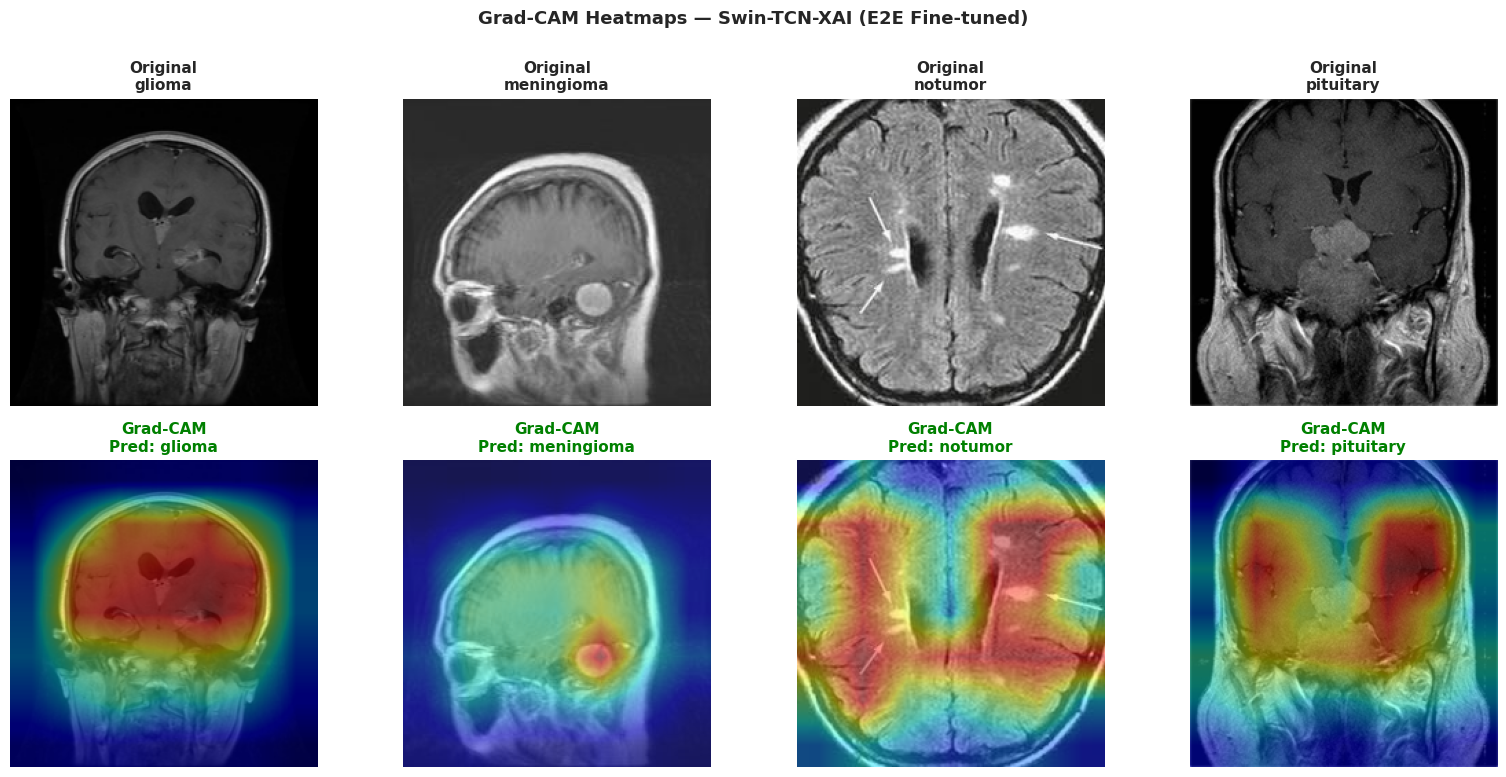

In [31]:
xai_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

def get_sample_paths(test_dir, class_names, n_per_class=1):
    samples = []
    for cls in class_names:
        cls_dir = os.path.join(test_dir, cls)
        if not os.path.isdir(cls_dir):
            for alt in ['notumor','no_tumor','NoTumor']:
                alt_dir = os.path.join(test_dir, alt)
                if os.path.isdir(alt_dir):
                    cls_dir = alt_dir; break
        if not os.path.isdir(cls_dir):
            print(f"⚠️  Folder not found: {cls}"); continue
        imgs = [f for f in os.listdir(cls_dir)
                if f.lower().endswith(('.jpg','.png','.jpeg'))]
        for img_f in imgs[:n_per_class]:
            samples.append((os.path.join(cls_dir, img_f), cls))
    return samples

sample_paths = get_sample_paths(TEST_DIR, class_names, n_per_class=1)
print(f"✅ Found {len(sample_paths)} sample images: {[s[1] for s in sample_paths]}")

fig, axes = plt.subplots(2, len(sample_paths), figsize=(4*len(sample_paths), 8))

for col, (img_path, cls_name) in enumerate(sample_paths):
    img_pil = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_t   = xai_transform(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        feat = e2e_model.swin(img_t)        # [1, 7, 7, 768]
        B, H, W, C = feat.shape
        feat = feat.view(B, H*W, C)         # [1, 49, 768]

    target_idx = class_names.index(cls_name) if cls_name in class_names else 0
    cam, pred  = generate_gradcam(feat.squeeze(0), target_idx)
    pred_name  = class_names[pred]
    overlay    = overlay_gradcam(cam, img_pil)

    axes[0, col].imshow(np.array(img_pil))
    axes[0, col].set_title(f"Original\n{cls_name}", fontsize=11, fontweight='bold')
    axes[0, col].axis('off')

    color = 'green' if pred_name == cls_name else 'red'
    axes[1, col].imshow(overlay)
    axes[1, col].set_title(f"Grad-CAM\nPred: {pred_name}",
                            fontsize=11, color=color, fontweight='bold')
    axes[1, col].axis('off')

plt.suptitle('Grad-CAM Heatmaps — Swin-TCN-XAI (E2E Fine-tuned)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## phase 14 :SHAP Setup & Compute

In [32]:
import shap

N_SHAP_BG   = 100
N_SHAP_EVAL = 50

class ModelForSHAP(nn.Module):
    def __init__(self, base_model, seq_len, feat_dim):
        super().__init__()
        self.base     = base_model
        self.seq_len  = seq_len
        self.feat_dim = feat_dim
    def forward(self, x_flat):
        x = x_flat.view(-1, self.seq_len, self.feat_dim)
        # Pass through TCN + classifier of e2e_model
        x = x.permute(0, 2, 1)
        x = self.base.tcn(x)
        return self.base.classifier(x)

shap_model = ModelForSHAP(e2e_model, SEQ_LEN, FEAT_DIM).to(device)
shap_model.eval()

train_flat = train_feat_e2e.view(len(train_feat_e2e), -1).numpy()
test_flat  = test_feat_e2e.view(len(test_feat_e2e),  -1).numpy()

idx_bg  = np.random.choice(len(train_flat), N_SHAP_BG,   replace=False)
idx_ev  = np.random.choice(len(test_flat),  N_SHAP_EVAL, replace=False)
bg_data = torch.tensor(train_flat[idx_bg], dtype=torch.float32).to(device)
ev_data = torch.tensor(test_flat[idx_ev],  dtype=torch.float32).to(device)

print(f"✅ SHAP background: {bg_data.shape}  |  eval: {ev_data.shape}")
explainer   = shap.DeepExplainer(shap_model, bg_data)
shap_values = explainer.shap_values(ev_data)
print(f"✅ SHAP values computed. Shape: {np.array(shap_values).shape}")

✅ SHAP background: torch.Size([100, 37632])  |  eval: torch.Size([50, 37632])
✅ SHAP values computed. Shape: (50, 37632, 4)


## SHAP Visualization

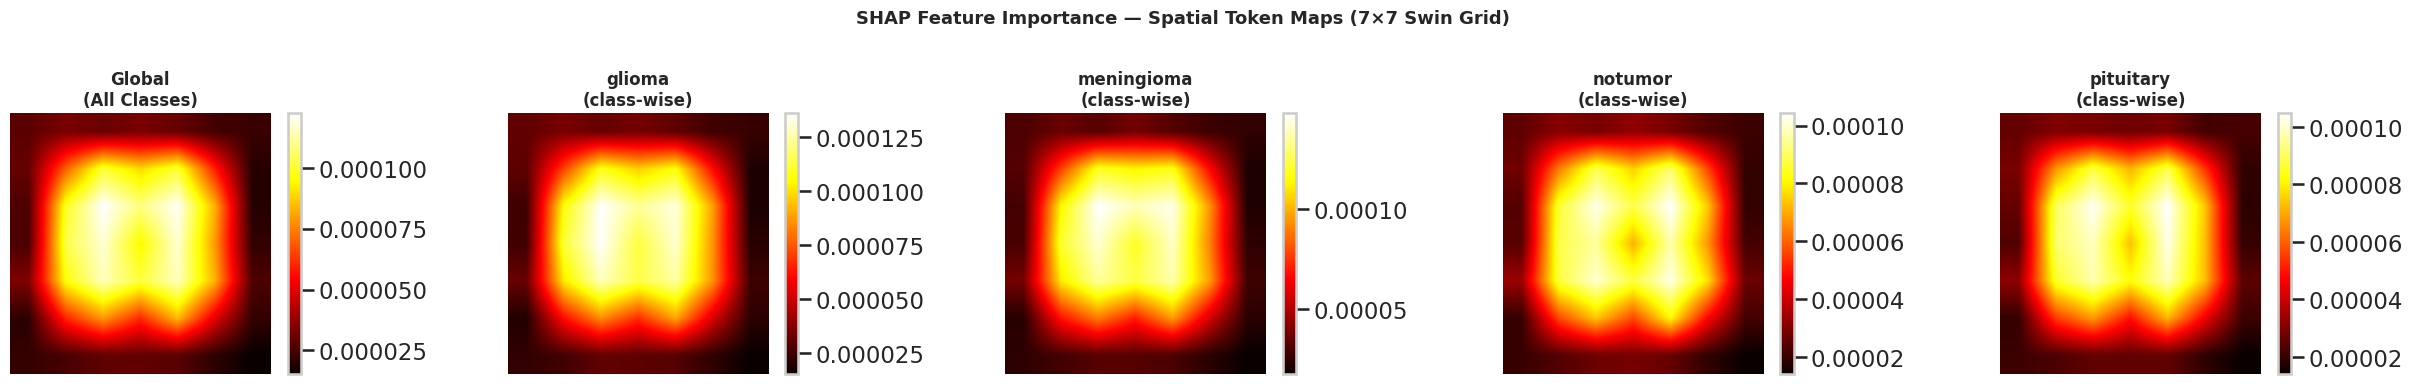

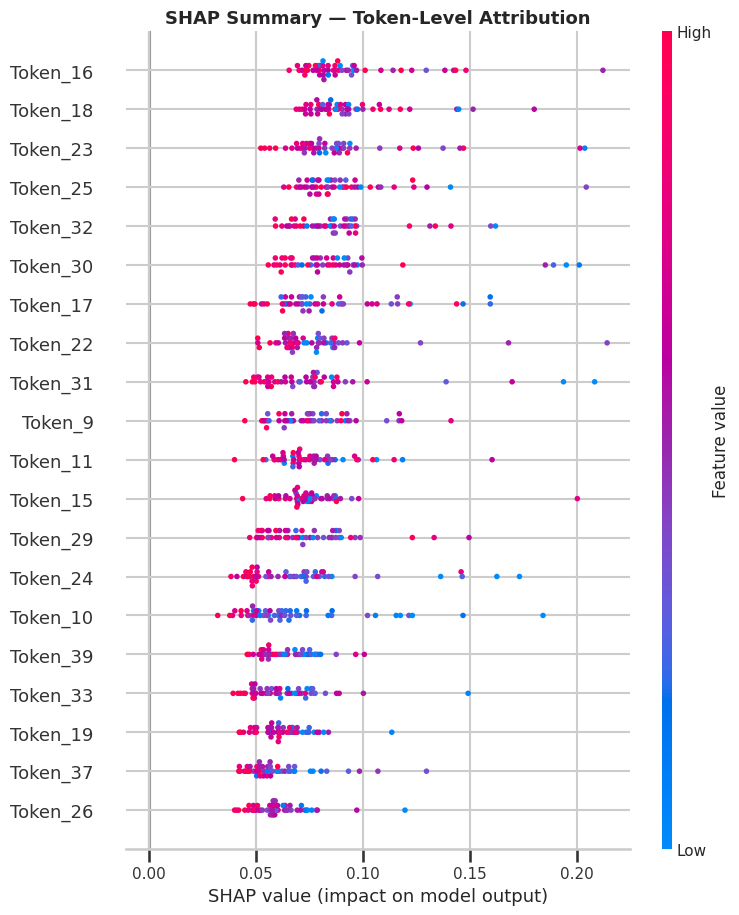


📊 Top-10 Most Important Swin Tokens (SHAP):
Rank |      Token |  Mean |SHAP|
--------------------------------
   1 |   Token_16 |     0.093984
   2 |   Token_18 |     0.093276
   3 |   Token_23 |     0.090388
   4 |   Token_25 |     0.090263
   5 |   Token_32 |     0.088734
   6 |   Token_30 |     0.088374
   7 |   Token_17 |     0.083546
   8 |   Token_22 |     0.078953
   9 |   Token_31 |     0.078005
  10 |    Token_9 |     0.077426


In [33]:
shap_arr = np.array(shap_values)

# Handle both output shapes from DeepExplainer
if shap_arr.ndim == 3 and shap_arr.shape[-1] == NUM_CLASSES:
    shap_arr = shap_arr.transpose(2, 0, 1)   # [num_classes, N, D]

mean_abs         = np.abs(shap_arr).mean(axis=1)
mean_abs_spatial = mean_abs.reshape(NUM_CLASSES, SEQ_LEN, FEAT_DIM).mean(axis=2)
global_token_imp = mean_abs_spatial.mean(axis=0)
shap_map         = global_token_imp.reshape(7, 7)

fig, axes = plt.subplots(1, NUM_CLASSES+1, figsize=(5*(NUM_CLASSES+1), 4))

im = axes[0].imshow(shap_map, cmap='hot', interpolation='bilinear')
axes[0].set_title('Global\n(All Classes)', fontsize=12, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im, ax=axes[0], fraction=0.046)

for i, cls in enumerate(class_names):
    cls_map = mean_abs_spatial[i].reshape(7, 7)
    im2 = axes[i+1].imshow(cls_map, cmap='hot', interpolation='bilinear')
    axes[i+1].set_title(f'{cls}\n(class-wise)', fontsize=12, fontweight='bold')
    axes[i+1].axis('off')
    plt.colorbar(im2, ax=axes[i+1], fraction=0.046)

plt.suptitle('SHAP Feature Importance — Spatial Token Maps (7×7 Swin Grid)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Summary plot
shap_mean   = np.abs(shap_arr).mean(axis=0)
shap_token  = shap_mean.reshape(N_SHAP_EVAL, SEQ_LEN, FEAT_DIM).sum(axis=2)
ev_token    = ev_data.cpu().numpy().reshape(N_SHAP_EVAL, SEQ_LEN, FEAT_DIM).sum(axis=2)
token_names = [f'Token_{i}' for i in range(SEQ_LEN)]

plt.figure()
shap.summary_plot(shap_token, ev_token, feature_names=token_names,
                  max_display=20, show=False)
plt.title('SHAP Summary — Token-Level Attribution', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Top-10 table
token_imp = np.abs(shap_token).mean(axis=0)
top10     = np.argsort(token_imp)[::-1][:10]
print("\n📊 Top-10 Most Important Swin Tokens (SHAP):")
print(f"{'Rank':>4} | {'Token':>10} | {'Mean |SHAP|':>12}")
print("-" * 32)
for rank, idx in enumerate(top10, 1):
    print(f"{rank:>4} | {token_names[idx]:>10} | {token_imp[idx]:>12.6f}")

## phase 15 :LIME

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

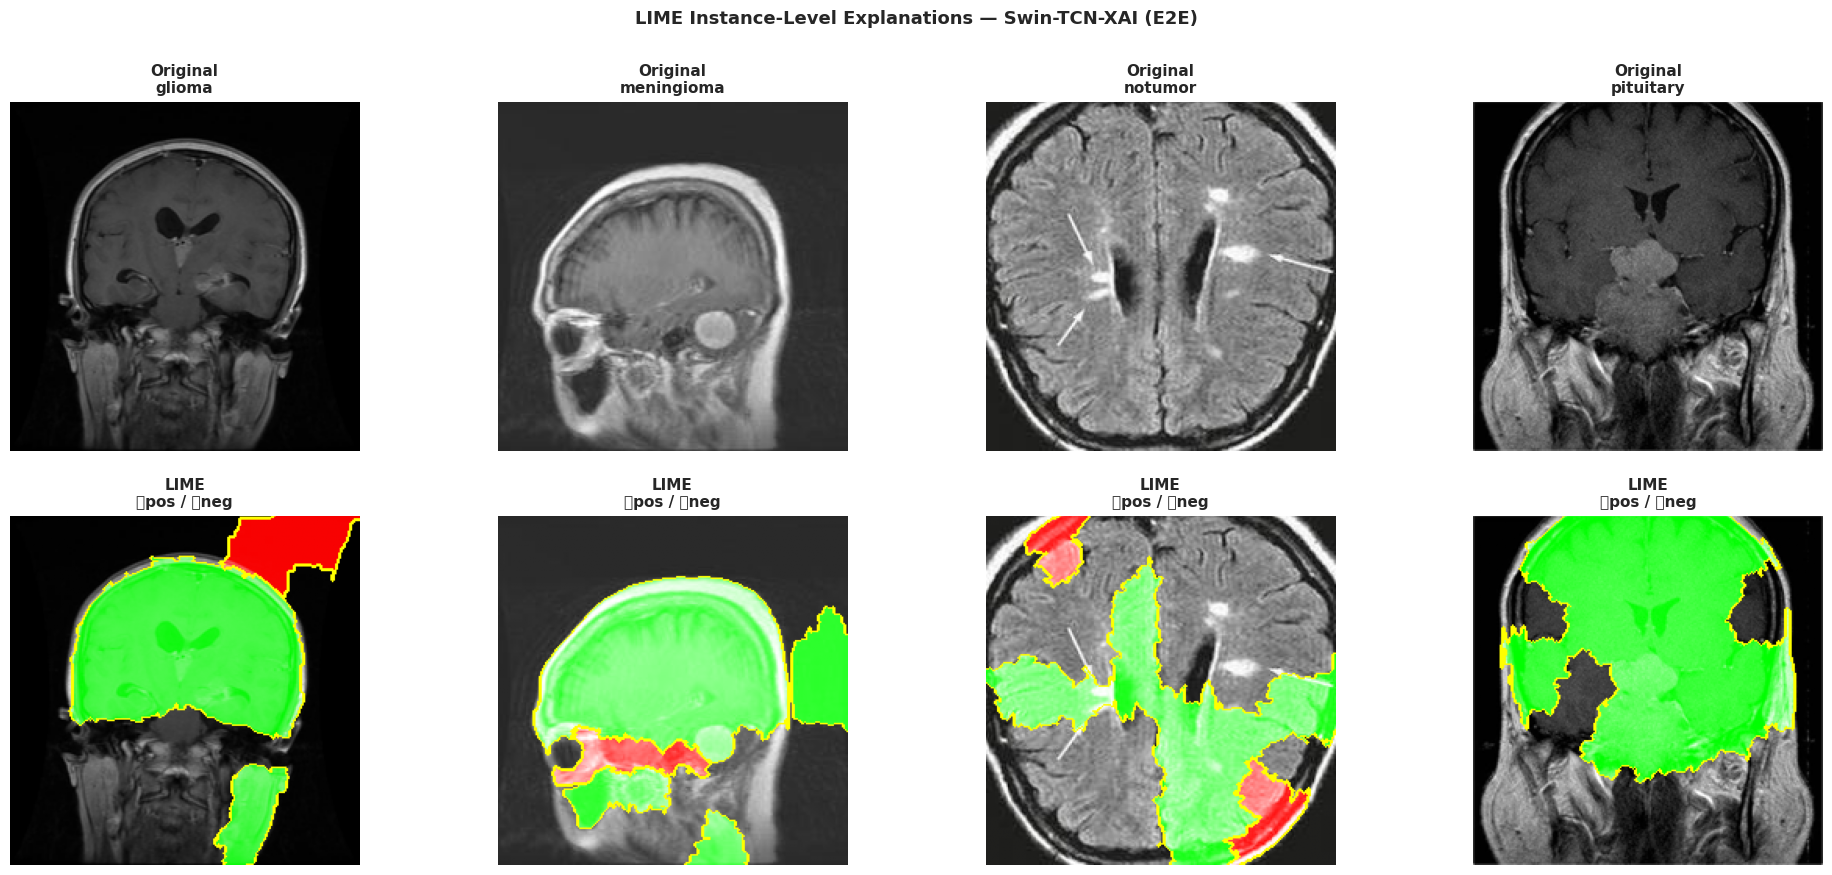

In [34]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

def lime_predict(images_np):
    e2e_model.eval()
    pil_transform = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])
    all_probs = []
    with torch.no_grad():
        for img_np in images_np:
            if img_np.dtype != np.uint8:
                img_np = (img_np * 255).astype(np.uint8)
            t    = pil_transform(Image.fromarray(img_np).convert('RGB')).unsqueeze(0).to(device)
            out  = e2e_model(t)
            prob = torch.softmax(out, dim=1).cpu().numpy()[0]
            all_probs.append(prob)
    return np.array(all_probs)

lime_explainer = lime_image.LimeImageExplainer()

n_cols = len(sample_paths)
fig, axes = plt.subplots(2, n_cols, figsize=(5*n_cols, 9))

for col, (img_path, cls_name) in enumerate(sample_paths):
    img_pil = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_np  = np.array(img_pil)
    target_idx = class_names.index(cls_name) if cls_name in class_names else 0

    explanation = lime_explainer.explain_instance(
        img_np, lime_predict, top_labels=NUM_CLASSES,
        hide_color=0, num_samples=300)
    temp, mask = explanation.get_image_and_mask(
        target_idx, positive_only=False, num_features=8,
        hide_rest=False, min_weight=0.0)

    axes[0, col].imshow(img_np)
    axes[0, col].set_title(f"Original\n{cls_name}", fontsize=11, fontweight='bold')
    axes[0, col].axis('off')

    axes[1, col].imshow(mark_boundaries(temp/255.0, mask))
    axes[1, col].set_title("LIME\n🟢pos / 🔴neg", fontsize=11, fontweight='bold')
    axes[1, col].axis('off')

plt.suptitle('LIME Instance-Level Explanations — Swin-TCN-XAI (E2E)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## More Good Lime Figure

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

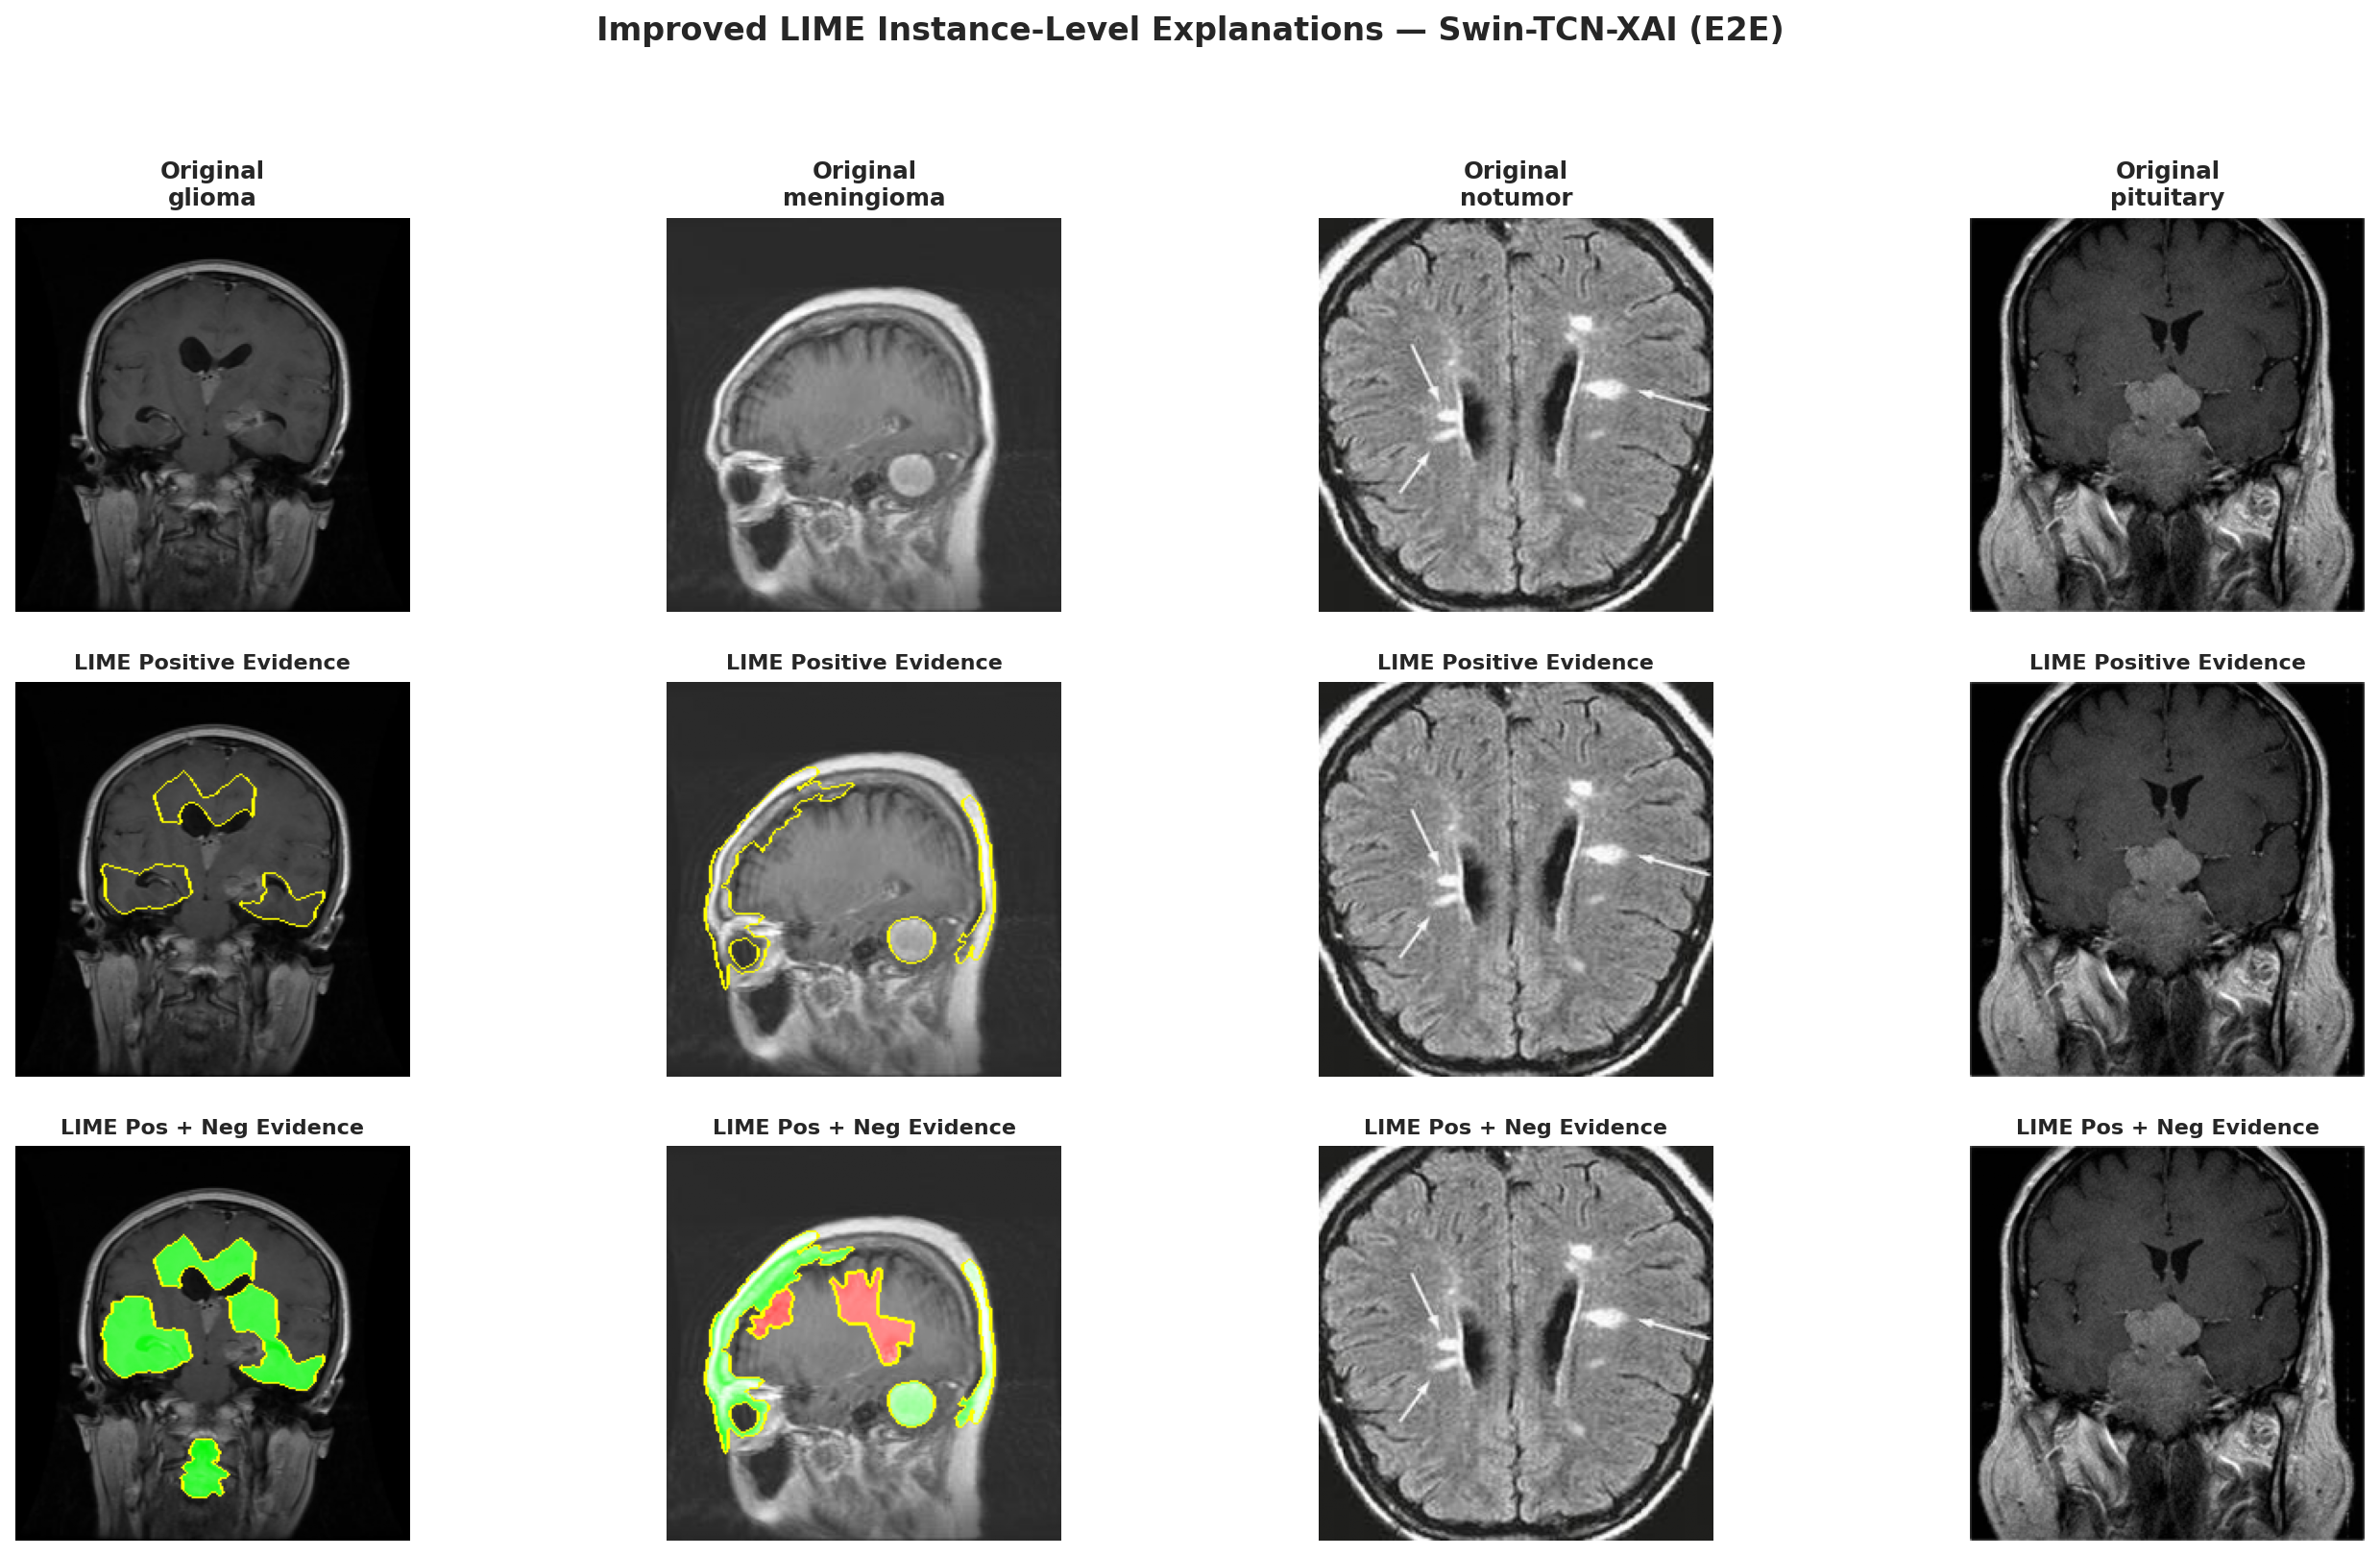

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T

from PIL import Image
from lime import lime_image
from skimage.segmentation import slic, mark_boundaries

# -----------------------------
# LIME prediction function
# -----------------------------
def lime_predict(images_np):
    e2e_model.eval()

    preprocess = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    probs = []

    with torch.no_grad():
        for img_np in images_np:
            img_np = np.clip(img_np, 0, 255).astype(np.uint8)

            img_pil = Image.fromarray(img_np).convert("RGB")
            x = preprocess(img_pil).unsqueeze(0).to(device)

            logits = e2e_model(x)
            prob = torch.softmax(logits, dim=1).cpu().numpy()[0]
            probs.append(prob)

    return np.array(probs)


# -----------------------------
# Better segmentation
# -----------------------------
def segmentation_fn(image):
    return slic(
        image,
        n_segments=120,
        compactness=12,
        sigma=1,
        start_label=1
    )


lime_explainer = lime_image.LimeImageExplainer(random_state=42)

n_cols = len(sample_paths)
fig, axes = plt.subplots(
    3,
    n_cols,
    figsize=(4.5 * n_cols, 10),
    dpi=160
)

for col, (img_path, cls_name) in enumerate(sample_paths):

    img_pil = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_np = np.array(img_pil)

    target_idx = class_names.index(cls_name)

    explanation = lime_explainer.explain_instance(
        img_np,
        lime_predict,
        labels=[target_idx],
        hide_color=0,
        num_samples=1000,
        segmentation_fn=segmentation_fn,
        random_seed=42
    )

    # Positive regions
    pos_img, pos_mask = explanation.get_image_and_mask(
        label=target_idx,
        positive_only=True,
        num_features=5,
        hide_rest=False,
        min_weight=0.02
    )

    # Positive + negative regions
    full_img, full_mask = explanation.get_image_and_mask(
        label=target_idx,
        positive_only=False,
        num_features=8,
        hide_rest=False,
        min_weight=0.02
    )

    # Original image
    axes[0, col].imshow(img_np, cmap="gray")
    axes[0, col].set_title(
        f"Original\n{cls_name}",
        fontsize=11,
        fontweight="bold"
    )
    axes[0, col].axis("off")

    # Positive-only LIME
    axes[1, col].imshow(mark_boundaries(pos_img / 255.0, pos_mask))
    axes[1, col].set_title(
        "LIME Positive Evidence",
        fontsize=10,
        fontweight="bold"
    )
    axes[1, col].axis("off")

    # Positive and negative LIME
    axes[2, col].imshow(mark_boundaries(full_img / 255.0, full_mask))
    axes[2, col].set_title(
        "LIME Pos + Neg Evidence",
        fontsize=10,
        fontweight="bold"
    )
    axes[2, col].axis("off")

plt.suptitle(
    "Improved LIME Instance-Level Explanations — Swin-TCN-XAI (E2E)",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

## phase 16 : Final Summary

In [35]:
print("=" * 65)
print("  SWIN-TCN-XAI (E2E) — FINAL RESULTS SUMMARY")
print("  (Use these ACTUAL numbers in your paper)")
print("=" * 65)
print(f"  Overall Accuracy    : {overall_acc*100:.2f}%")
print(f"  Macro Precision     : {macro_prec*100:.2f}%")
print(f"  Macro Recall        : {macro_rec*100:.2f}%")
print(f"  Macro F1-Score      : {macro_f1*100:.2f}%")
print(f"  Best Epoch          : {best_epoch_e2e}/{E2E_EPOCHS}")
print()
print("  Per-class results:")
report_dict = classification_report(all_true, all_preds,
                                     target_names=class_names, output_dict=True)
for cls in class_names:
    r = report_dict[cls]
    print(f"    {cls:12s}: P={r['precision']:.4f}  R={r['recall']:.4f}"
          f"  F1={r['f1-score']:.4f}  N={int(r['support'])}")
print()
print("  Model       : SwinTCNEndToEnd (28M params)")
print("  Backbone LR : 2e-5  |  Head LR: 3e-4 (AdamW)")
print("  Loss        : CrossEntropyLoss (label_smoothing=0.1)")
print(f"  Epochs      : {E2E_EPOCHS}  |  Batch: {BATCH_SIZE}")
print("  XAI         : Grad-CAM (TCN.network[-1]) + SHAP + LIME")
print("=" * 65)

  SWIN-TCN-XAI (E2E) — FINAL RESULTS SUMMARY
  (Use these ACTUAL numbers in your paper)
  Overall Accuracy    : 99.41%
  Macro Precision     : 99.40%
  Macro Recall        : 99.48%
  Macro F1-Score      : 99.44%
  Best Epoch          : 17/30

  Per-class results:
    glioma      : P=0.9967  R=0.9884  F1=0.9925  N=603
    meningioma  : P=0.9863  R=0.9931  F1=0.9897  N=436
    notumor     : P=1.0000  R=1.0000  F1=1.0000  N=389
    pituitary   : P=0.9930  R=0.9977  F1=0.9953  N=429

  Model       : SwinTCNEndToEnd (28M params)
  Backbone LR : 2e-5  |  Head LR: 3e-4 (AdamW)
  Loss        : CrossEntropyLoss (label_smoothing=0.1)
  Epochs      : 30  |  Batch: 32
  XAI         : Grad-CAM (TCN.network[-1]) + SHAP + LIME
